Starting HYBRID Region Growing with 98 seeds using a Priority Queue...
Hybrid Region Growing complete. Processed 13960 pixels.
Performing geometric analysis: Triangle Fitting and Medial Axis...


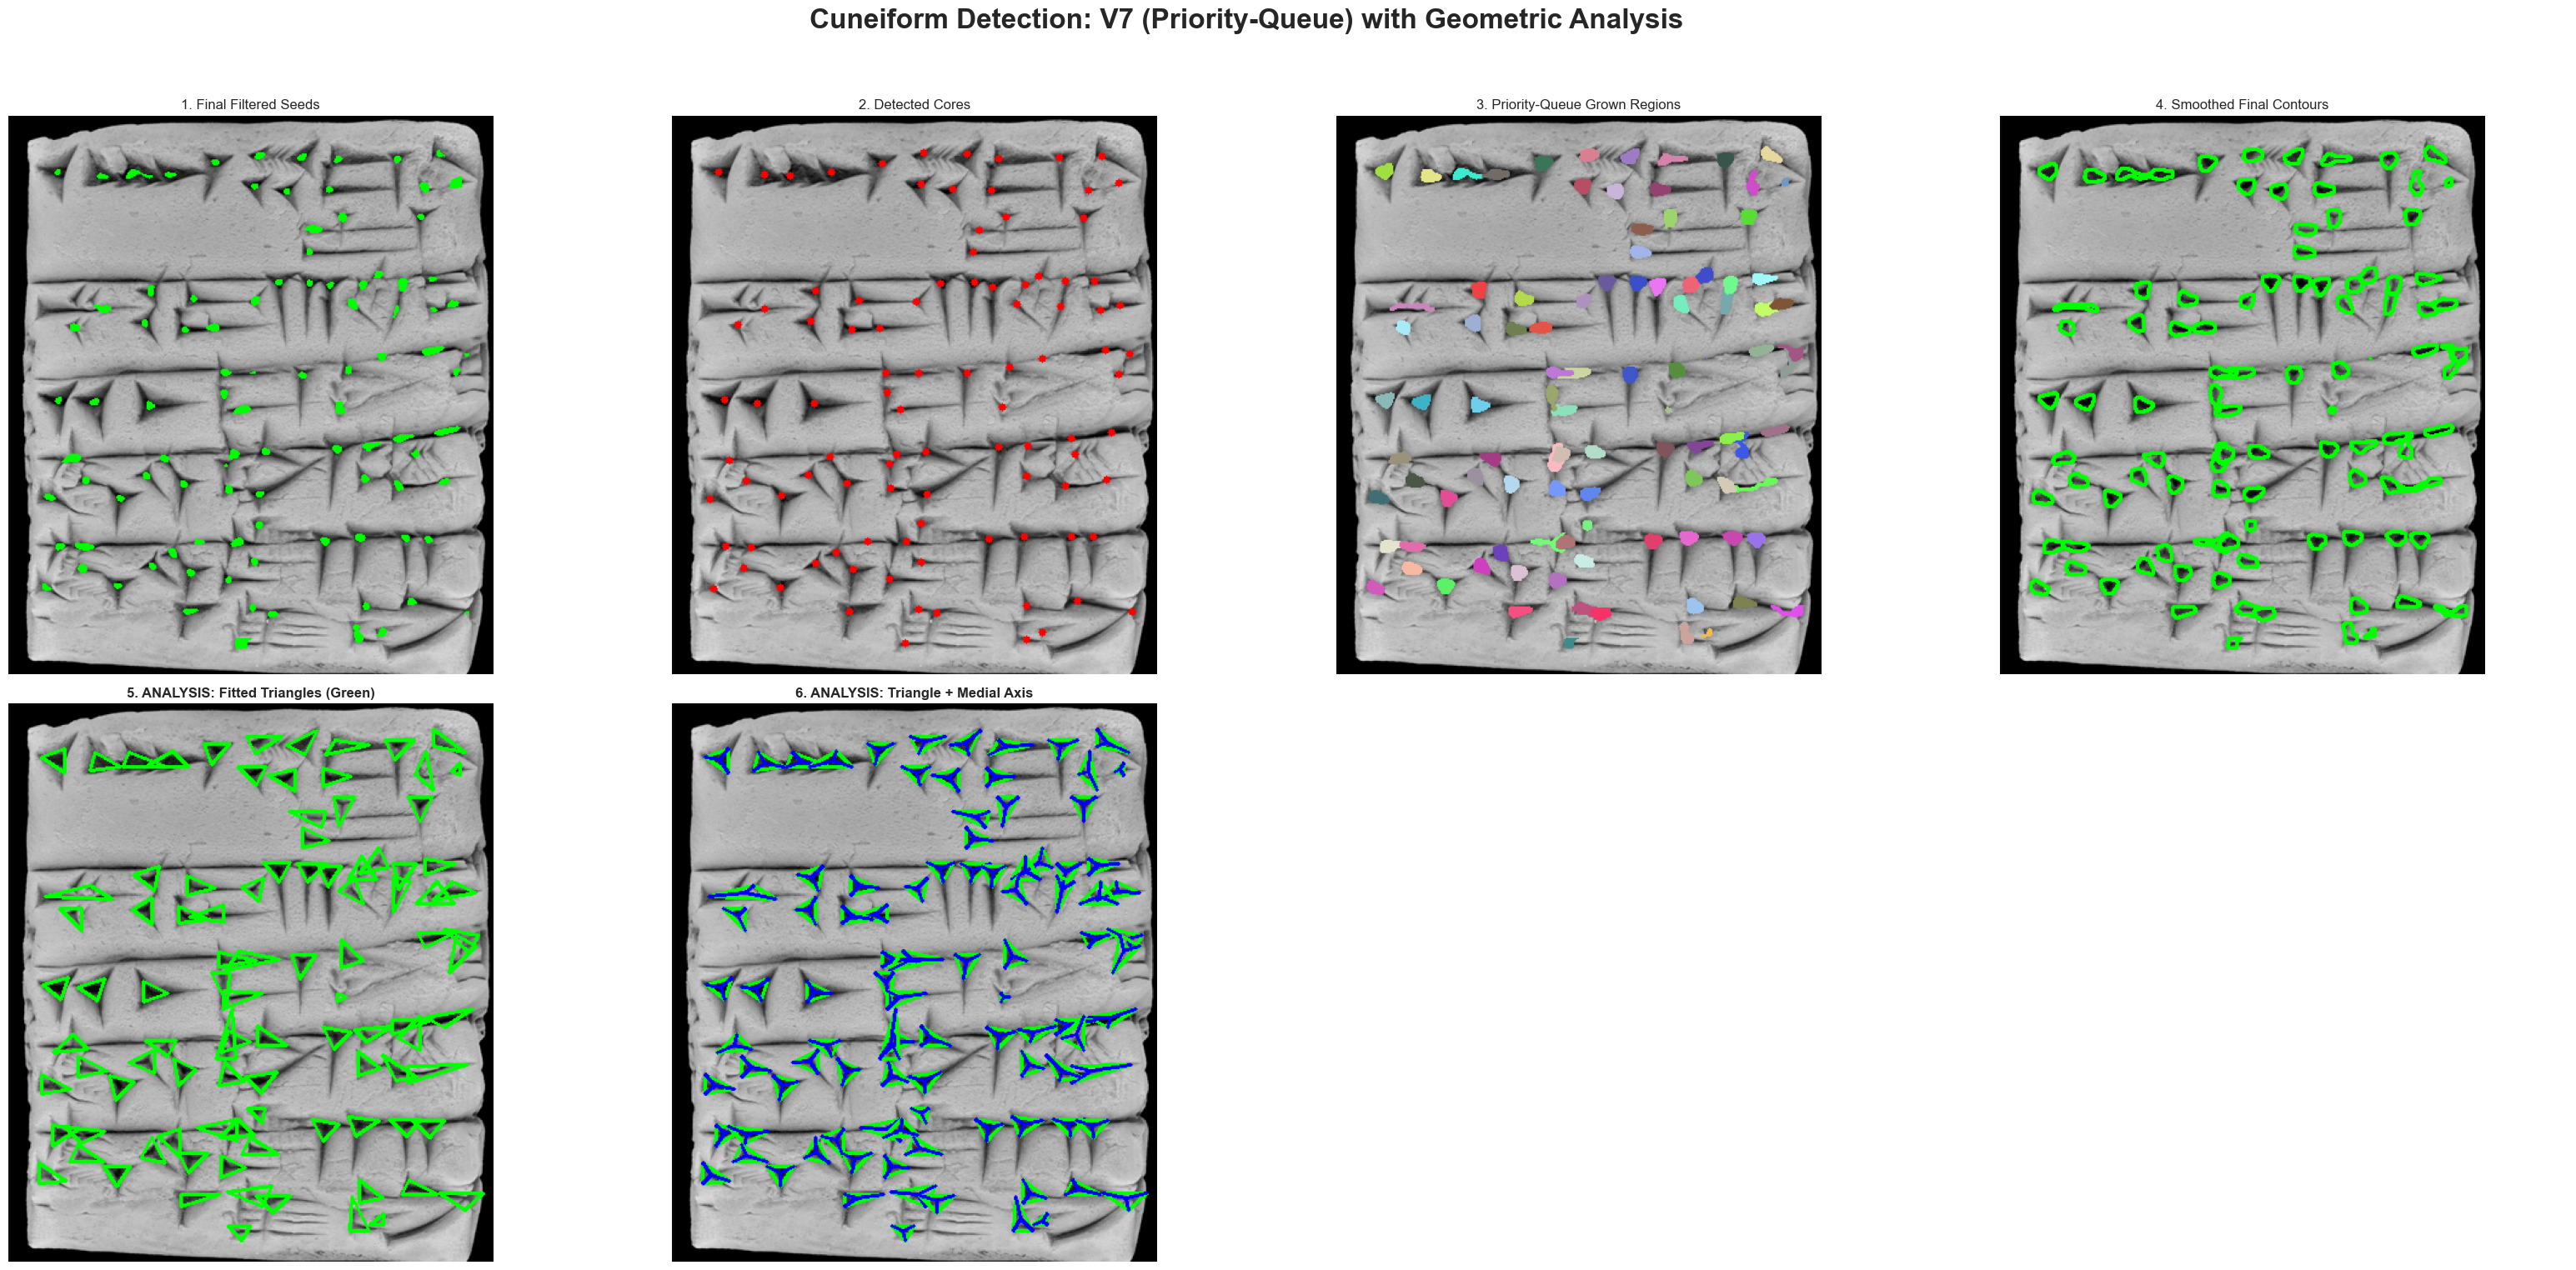

In [1]:
# -*- coding: utf-8 -*-
"""
Cuneiform Wedge Detection Script - V7 (with Geometric Analysis Add-on)

This script uses the Priority Queue (heapq) based region growing from V7
and adds the geometric analysis steps (triangle fitting and medial axis)
as requested.

-   Finds the minimum enclosing triangle for each detected region.
-   Visualizes:
    1.  The fitted triangles (green) on the original image.
    2.  The triangles (green) along with their medial axes (yellow) on a separate plot.
"""

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from collections import deque
import random
import heapq  # For the priority queue

# ==============================================================================
# 1. PARAMETERS (From user's V7 code)
# ==============================================================================
# --- Input File ---
IMAGE_PATH = '12.jpg'

# --- Pre-processing & Filters ---
SMOOTHING_KERNEL_SIZE = (11, 11)
BORDER_MARGIN = 15
INITIAL_BRIGHTNESS_THRESHOLD = 0
FILLING_ITERATIONS = 20
SEED_THRESHOLD = 10
SHAPE_MIN_AREA = 2
SHAPE_MAX_AREA = 100
SHAPE_ASPECT_RATIO = [0.1, 90.0]
SHAPE_SOLIDITY_THRESHOLD = 0.1
SHAPE_POLY_APPROX_FACTOR = 0.1
SHAPE_VERTEX_COUNT = [2, 10]
SHAPE_OPENING_KERNEL_SIZE = (5, 5)

# --- Region Growing ---
GROWTH_SIMILARITY_THRESHOLD = 15
MAX_GROWTH_AREA = 150
MIN_ECCENTRICITY = 0.0007
SHAPE_CHECK_INTERVAL = 15

# --- Visualization Control Parameters ---
CORE_MARKER_RADIUS = 3
CONTOUR_THICKNESS = 2
CONTOUR_SMOOTHING_KERNEL_SIZE = 7

# ==============================================================================
# 2. HELPER FUNCTIONS (Unchanged)
# ==============================================================================
def calculate_eccentricity(points):
    if len(points) < 5: return 1.0
    contour = np.array(points, dtype=np.int32).reshape(-1, 1, 2)
    try:
        (center, axes, angle) = cv.fitEllipse(contour)
        major_axis, minor_axis = max(axes), min(axes)
        if major_axis < 1e-6: return 0.0
        return np.sqrt(1 - (minor_axis / major_axis)**2)
    except cv.error:
        return 1.0

def filter_by_average_brightness(input_mask, reference_image):
    global_avg_brightness = np.mean(reference_image)
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(input_mask, 8, cv.CV_32S)
    filtered_mask = np.zeros_like(input_mask)
    for i in range(1, num_labels):
        component_mask = (labels == i)
        avg_brightness_of_component = np.mean(reference_image[component_mask])
        if avg_brightness_of_component < global_avg_brightness:
            filtered_mask[component_mask] = 255
    return filtered_mask

def filter_for_cuneiform_wedges(input_mask, params):
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(input_mask, 8, cv.CV_32S)
    final_mask = np.zeros_like(input_mask, dtype=np.uint8)
    opening_kernel = cv.getStructuringElement(cv.MORPH_RECT, params['opening_kernel_size'])
    for i in range(1, num_labels):
        area = stats[i, cv.CC_STAT_AREA]
        if not (params['min_area'] <= area <= params['max_area']): continue
        original_component_mask = (labels == i).astype(np.uint8) * 255
        processed_mask = cv.morphologyEx(original_component_mask, cv.MORPH_OPEN, opening_kernel)
        contours_source = original_component_mask if cv.countNonZero(processed_mask) == 0 else processed_mask
        contours, _ = cv.findContours(contours_source, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        if not contours: continue
        contour = max(contours, key=cv.contourArea)
        analysis_area = cv.contourArea(contour)
        if analysis_area < params['min_area']: continue
        _, (w, h), _ = cv.minAreaRect(contour)
        if w > h: w, h = h, w
        aspect_ratio = h / w if w > 1e-3 else 1000
        hull = cv.convexHull(contour)
        hull_area = cv.contourArea(hull)
        solidity = float(analysis_area) / hull_area if hull_area > 1e-3 else 0
        perimeter = cv.arcLength(contour, True)
        approx = cv.approxPolyDP(contour, params['poly_approx_factor'] * perimeter, True)
        num_vertices = len(approx)
        if (params['aspect_ratio'][0] <= aspect_ratio <= params['aspect_ratio'][1]) and \
           (solidity >= params['solidity_threshold']) and \
           (params['vertex_count'][0] <= num_vertices <= params['vertex_count'][1]):
            final_mask[labels == i] = 255
    return final_mask

# ==============================================================================
# 3. MAIN WORKFLOW (Unchanged)
# ==============================================================================
try:
    original_color_image = cv.imread(IMAGE_PATH)
    if original_color_image is None: raise FileNotFoundError(f"Image not found at: {IMAGE_PATH}")
    original_image = cv.cvtColor(original_color_image, cv.COLOR_BGR2GRAY)
except (FileNotFoundError, Exception) as e:
    print(f"Error: {e}"); exit()

h, w = original_image.shape
border_mask = np.zeros(original_image.shape, dtype=np.uint8); border_mask[BORDER_MARGIN:h-BORDER_MARGIN, BORDER_MARGIN:w-BORDER_MARGIN] = 255
brightness_mask = (original_image >= INITIAL_BRIGHTNESS_THRESHOLD).astype(np.uint8) * 255
processing_area_mask = cv.bitwise_and(border_mask, brightness_mask)

smoothed_image = cv.blur(original_image, SMOOTHING_KERNEL_SIZE).astype(np.float32)
processed_image = smoothed_image.copy()

depth_by_visits = np.zeros_like(original_image, dtype=np.uint16)
kernel_3x3 = np.ones((3, 3), np.uint8)
for _ in range(FILLING_ITERATIONS):
    min_filtered_image = cv.erode(processed_image, kernel_3x3)
    local_minima_mask = (processed_image == min_filtered_image) & (processed_image < 255) & (processing_area_mask == 255)
    processed_image[local_minima_mask] += 1
    depth_by_visits[local_minima_mask] += 1
initial_seeds_mask = (depth_by_visits >= SEED_THRESHOLD).astype(np.uint8) * 255
brightness_filtered_mask = filter_by_average_brightness(initial_seeds_mask, original_image)
shape_filter_params = {
    'min_area': SHAPE_MIN_AREA, 'max_area': SHAPE_MAX_AREA, 'aspect_ratio': SHAPE_ASPECT_RATIO,
    'solidity_threshold': SHAPE_SOLIDITY_THRESHOLD, 'poly_approx_factor': SHAPE_POLY_APPROX_FACTOR,
    'vertex_count': SHAPE_VERTEX_COUNT, 'opening_kernel_size': SHAPE_OPENING_KERNEL_SIZE
}
final_filtered_mask = filter_for_cuneiform_wedges(brightness_filtered_mask, shape_filter_params)

# ==============================================================================
# 4. POST-PROCESSING: CORE DETECTION (Unchanged)
# ==============================================================================
num_labels, labels_map_components, stats, _ = cv.connectedComponentsWithStats(final_filtered_mask, 8, cv.CV_32S)
cores_on_original_image = original_color_image.copy()
seed_points = []
for i in range(1, num_labels):
    component_mask = (labels_map_components == i)
    component_brightness_values = original_image[component_mask]
    if component_brightness_values.size == 0: continue
    min_val = np.min(component_brightness_values)
    core_pixels_mask = component_mask & (original_image == min_val)
    core_coords = np.argwhere(core_pixels_mask)
    if core_coords.size > 0:
        core_y, core_x = core_coords[0]
        cv.circle(cores_on_original_image, (core_x, core_y), CORE_MARKER_RADIUS, (0, 0, 255), -1)
        seed_points.append((core_y, core_x))

# ==============================================================================
# 5. HYBRID REGION GROWING (PRIORITY QUEUE) - (Unchanged)
# ==============================================================================
print(f"Starting HYBRID Region Growing with {len(seed_points)} seeds using a Priority Queue...")
grown_labels_map = np.zeros(original_image.shape, dtype=np.int32)
region_data = {}
priority_queue = []

for i, (y, x) in enumerate(seed_points, 1):
    if grown_labels_map[y, x] == 0:
        grown_labels_map[y, x] = i
        region_data[i] = {'points': [(y, x)], 'is_active': True, 'shape_check_counter': 0}
        heapq.heappush(priority_queue, (smoothed_image[y, x], y, x, i))

background_threshold = np.mean(original_image)
neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
pixel_process_count = 0

while priority_queue:
    parent_brightness, y, x, parent_label = heapq.heappop(priority_queue)
    pixel_process_count += 1
    if not region_data.get(parent_label, {}).get('is_active', False): continue
    for dy, dx in neighbors:
        ny, nx = y + dy, x + dx
        if not (0 <= ny < h and 0 <= nx < w): continue
        if grown_labels_map[ny, nx] != 0: continue
        if processing_area_mask[ny, nx] == 0: continue
        neighbor_brightness = smoothed_image[ny, nx]
        is_similar = abs(neighbor_brightness - parent_brightness) < GROWTH_SIMILARITY_THRESHOLD
        is_below_background = neighbor_brightness < background_threshold
        if is_similar and is_below_background:
            region_info = region_data[parent_label]
            if len(region_info['points']) >= MAX_GROWTH_AREA:
                region_info['is_active'] = False
                continue
            region_info['shape_check_counter'] += 1
            if region_info['shape_check_counter'] % SHAPE_CHECK_INTERVAL == 0:
                ecc = calculate_eccentricity(region_info['points'])
                if ecc < MIN_ECCENTRICITY:
                    region_info['is_active'] = False
                    continue
            grown_labels_map[ny, nx] = parent_label
            region_info['points'].append((ny, nx))
            heapq.heappush(priority_queue, (neighbor_brightness, ny, nx, parent_label))

print(f"Hybrid Region Growing complete. Processed {pixel_process_count} pixels.")

# ==============================================================================
# 6. VISUALIZATION PREPARATION (## UPDATED to store contours)
# ==============================================================================
grown_regions_color_overlay = original_color_image.copy()
random.seed(42)
colors = [np.random.randint(50, 256, size=3).tolist() for _ in range(len(seed_points) + 1)]
unique_labels_grown = np.unique(grown_labels_map)
for label_id in unique_labels_grown:
    if label_id == 0: continue
    mask = (grown_labels_map == label_id)
    grown_regions_color_overlay[mask] = colors[label_id]

contours_on_original_image = original_color_image.copy()
final_contours = {} # ## NEW ##: Store contours for later geometric analysis

for label_id in unique_labels_grown:
    if label_id == 0: continue
    label_mask = np.uint8(grown_labels_map == label_id) * 255
    if CONTOUR_SMOOTHING_KERNEL_SIZE > 1:
        kernel_size = (CONTOUR_SMOOTHING_KERNEL_SIZE, CONTOUR_SMOOTHING_KERNEL_SIZE)
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
        smoothed_mask = cv.morphologyEx(label_mask, cv.MORPH_CLOSE, kernel)
        contours, _ = cv.findContours(smoothed_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    else:
        contours, _ = cv.findContours(label_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Keep the largest contour for this label
        largest_contour = max(contours, key=cv.contourArea)
        final_contours[label_id] = largest_contour # Store it
        cv.drawContours(contours_on_original_image, [largest_contour], -1, (0, 255, 0), CONTOUR_THICKNESS)


# ==============================================================================
# 7. ## NEW ##: GEOMETRIC ANALYSIS (TRIANGLE FITTING & MEDIAL AXIS)
# ==============================================================================
fitted_triangles_image = original_color_image.copy()
medial_axis_image = original_color_image.copy() # Will contain both triangle and axes

print("Performing geometric analysis: Triangle Fitting and Medial Axis...")
for label_id, contour in final_contours.items():
    if len(contour) < 3: continue

    retval, triangle = cv.minEnclosingTriangle(contour)
    if triangle is None: continue
    
    triangle_vertices = np.intp(triangle.reshape(-1, 2))
    
    # --- Task 1: Draw the fitted triangle (green) ---
    cv.drawContours(fitted_triangles_image, [triangle_vertices], 0, (0, 255, 0), CONTOUR_THICKNESS) # Green as requested

    # --- Task 2: Draw triangle and its medial axis on a separate image ---
    # a. Draw the triangle itself (green)
    cv.drawContours(medial_axis_image, [triangle_vertices], 0, (0, 255, 0), CONTOUR_THICKNESS)

    # b. Find the centroid
    v1, v2, v3 = triangle_vertices
    centroid = (int((v1[0] + v2[0] + v3[0]) / 3), int((v1[1] + v2[1] + v3[1]) / 3))

    # c. Draw lines from each vertex to the centroid (yellow)
    cv.line(medial_axis_image, tuple(v1), centroid, (255, 0, 0), CONTOUR_THICKNESS) # Bright yellow
    cv.line(medial_axis_image, tuple(v2), centroid, (255, 0, 0), CONTOUR_THICKNESS)
    cv.line(medial_axis_image, tuple(v3), centroid, (255, 0, 0), CONTOUR_THICKNESS)


# ==============================================================================
# 8. VISUALIZATION (Plotting) - ## UPDATED with new plots
# ==============================================================================
def create_opaque_overlay(background_img, mask, color):
    overlay = background_img.copy()
    overlay[mask == 255] = color
    return overlay

try: plt.style.use('seaborn-v0_8-darkgrid')
except: plt.style.use('seaborn-darkgrid')

# Increased plot grid to 2x4 for the 2 new visualizations
fig, axes = plt.subplots(2, 4, figsize=(32, 16))
axes = axes.ravel()
fig.suptitle("Cuneiform Detection: V7 (Priority-Queue) with Geometric Analysis", fontsize=24, weight='bold')

# --- Row 1: Original V7 Plots ---
axes[0].imshow(cv.cvtColor(create_opaque_overlay(original_color_image, final_filtered_mask, color=(0, 255, 0)), cv.COLOR_BGR2RGB))
axes[0].set_title("1. Final Filtered Seeds")
axes[1].imshow(cv.cvtColor(cores_on_original_image, cv.COLOR_BGR2RGB))
axes[1].set_title("2. Detected Cores")
axes[2].imshow(cv.cvtColor(grown_regions_color_overlay, cv.COLOR_BGR2RGB))
axes[2].set_title("3. Priority-Queue Grown Regions")
axes[3].imshow(cv.cvtColor(contours_on_original_image, cv.COLOR_BGR2RGB))
axes[3].set_title("4. Smoothed Final Contours")

# --- Row 2: NEW Geometric Analysis Plots ---
axes[4].imshow(cv.cvtColor(fitted_triangles_image, cv.COLOR_BGR2RGB))
axes[4].set_title("5. ANALYSIS: Fitted Triangles (Green)", weight='bold')
axes[5].imshow(cv.cvtColor(medial_axis_image, cv.COLOR_BGR2RGB))
axes[5].set_title("6. ANALYSIS: Triangle + Medial Axis", weight='bold')

# Hide unused plots
axes[6].axis('off')
axes[7].axis('off')

for i in range(6):
    axes[i].axis('off')
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Starting HYBRID Region Growing with 4 seeds using a Priority Queue...
Hybrid Region Growing complete. Processed 800 pixels.
Performing geometric analysis: Triangle Fitting and Medial Axis...


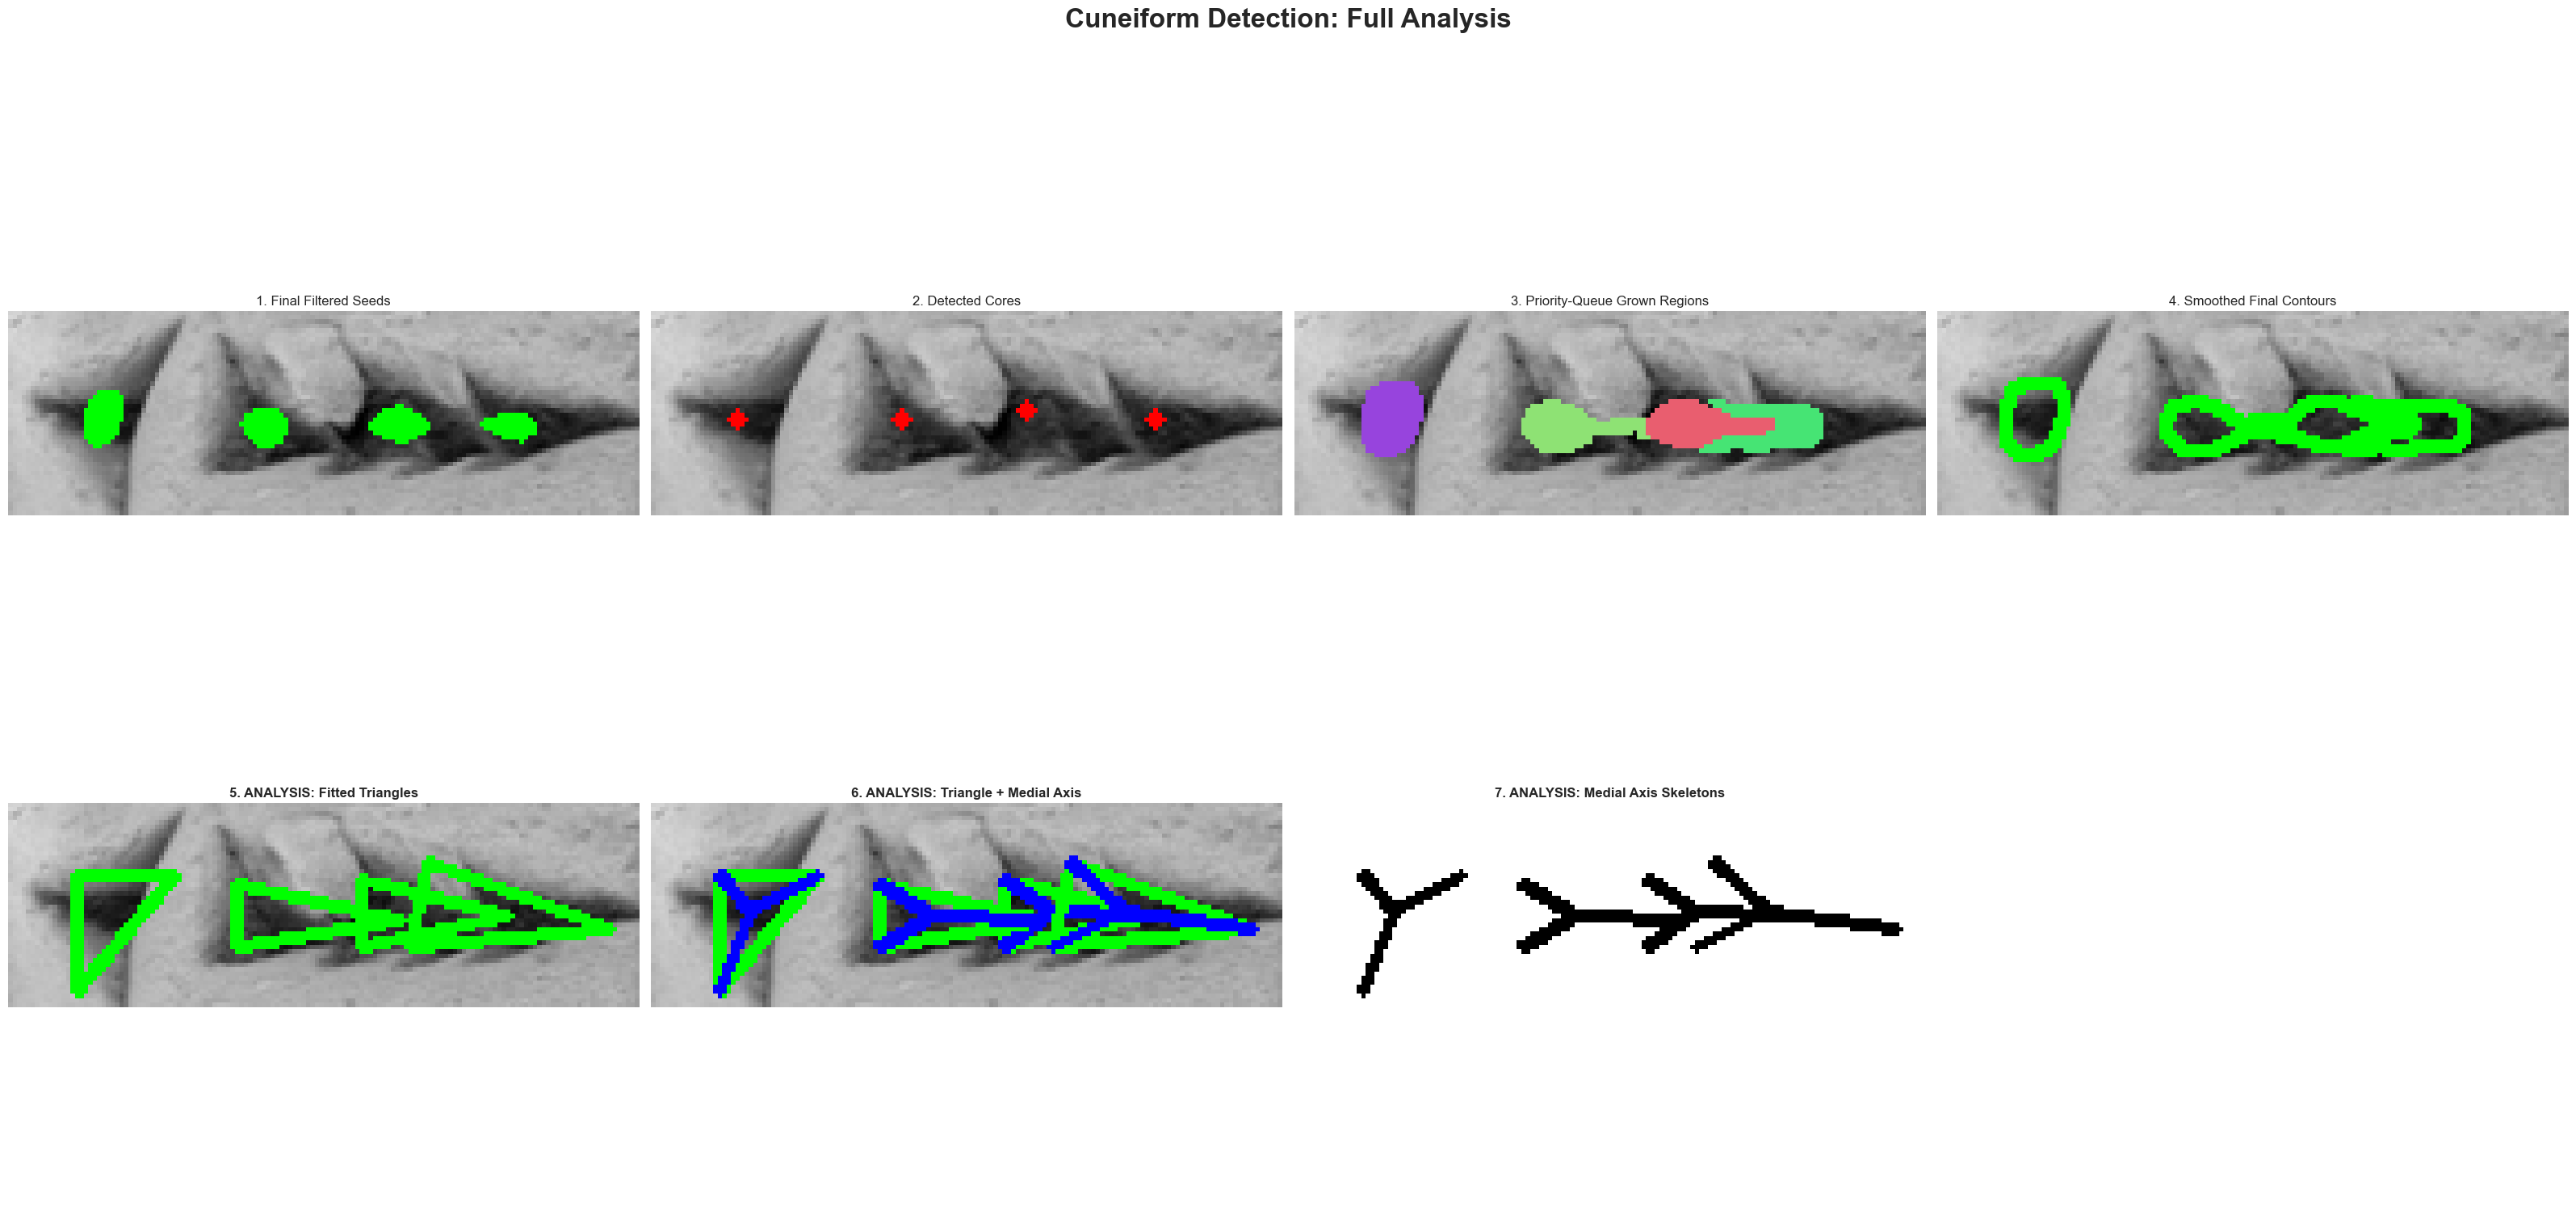

In [55]:
# -*- coding: utf-8 -*-
"""
Cuneiform Wedge Detection Script

This script performs classical image processing to detect, segment, and analyze
cuneiform wedges from images of clay tablets. It uses a combination of
morphological operations, hybrid region growing via priority queues, and 
geometric analysis (triangle fitting and medial axis extraction).

Author: Masoud Taleshpour
License: MIT
"""

import heapq
import random
from collections import deque

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. PARAMETERS
# ==============================================================================
# --- Input File ---
IMAGE_PATH = '12-1.jpg'

# --- Pre-processing & Filters ---
SMOOTHING_KERNEL_SIZE = (21, 21)
BORDER_MARGIN = 0
INITIAL_BRIGHTNESS_THRESHOLD = 0
FILLING_ITERATIONS = 20
SEED_THRESHOLD = 10

# --- Shape Filters ---
SHAPE_MIN_AREA = 10
SHAPE_MAX_AREA = 100
SHAPE_ASPECT_RATIO = [0.1, 90.0]
SHAPE_SOLIDITY_THRESHOLD = 0.2
SHAPE_POLY_APPROX_FACTOR = 0.1
SHAPE_VERTEX_COUNT = [2, 20]
SHAPE_OPENING_KERNEL_SIZE = (5, 5)

# --- Region Growing ---
GROWTH_SIMILARITY_THRESHOLD = 10
MAX_GROWTH_AREA = 200
MIN_ECCENTRICITY = 0.001
SHAPE_CHECK_INTERVAL = 2

# --- Visualization Control Parameters ---
CORE_MARKER_RADIUS = 2
CONTOUR_THICKNESS = 2
CONTOUR_SMOOTHING_KERNEL_SIZE = 5
SKELETON_LINE_THICKNESS = 2

# ==============================================================================
# 2. HELPER FUNCTIONS
# ==============================================================================
def calculate_eccentricity(points):
    if len(points) < 5: 
        return 1.0
    
    contour = np.array(points, dtype=np.int32).reshape(-1, 1, 2)
    try:
        (center, axes, angle) = cv.fitEllipse(contour)
        major_axis, minor_axis = max(axes), min(axes)
        if major_axis < 1e-6: 
            return 0.0
        return np.sqrt(1 - (minor_axis / major_axis)**2)
    except cv.error:
        return 1.0

def filter_by_average_brightness(input_mask, reference_image):
    global_avg_brightness = np.mean(reference_image)
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(input_mask, 8, cv.CV_32S)
    filtered_mask = np.zeros_like(input_mask)
    
    for i in range(1, num_labels):
        component_mask = (labels == i)
        avg_brightness_of_component = np.mean(reference_image[component_mask])
        if avg_brightness_of_component < global_avg_brightness:
            filtered_mask[component_mask] = 255
            
    return filtered_mask

def filter_for_cuneiform_wedges(input_mask, params):
    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(input_mask, 8, cv.CV_32S)
    final_mask = np.zeros_like(input_mask, dtype=np.uint8)
    opening_kernel = cv.getStructuringElement(cv.MORPH_RECT, params['opening_kernel_size'])
    
    for i in range(1, num_labels):
        area = stats[i, cv.CC_STAT_AREA]
        if not (params['min_area'] <= area <= params['max_area']): 
            continue
            
        original_component_mask = (labels == i).astype(np.uint8) * 255
        processed_mask = cv.morphologyEx(original_component_mask, cv.MORPH_OPEN, opening_kernel)
        contours_source = original_component_mask if cv.countNonZero(processed_mask) == 0 else processed_mask
        
        contours, _ = cv.findContours(contours_source, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        if not contours: 
            continue
            
        contour = max(contours, key=cv.contourArea)
        analysis_area = cv.contourArea(contour)
        if analysis_area < params['min_area']: 
            continue
            
        _, (w, h), _ = cv.minAreaRect(contour)
        if w > h: 
            w, h = h, w
        aspect_ratio = h / w if w > 1e-3 else 1000
        
        hull = cv.convexHull(contour)
        hull_area = cv.contourArea(hull)
        solidity = float(analysis_area) / hull_area if hull_area > 1e-3 else 0
        
        perimeter = cv.arcLength(contour, True)
        approx = cv.approxPolyDP(contour, params['poly_approx_factor'] * perimeter, True)
        num_vertices = len(approx)
        
        if (params['aspect_ratio'][0] <= aspect_ratio <= params['aspect_ratio'][1]) and \
           (solidity >= params['solidity_threshold']) and \
           (params['vertex_count'][0] <= num_vertices <= params['vertex_count'][1]):
            final_mask[labels == i] = 255
            
    return final_mask

def create_opaque_overlay(background_img, mask, color):
    overlay = background_img.copy()
    overlay[mask == 255] = color
    return overlay

# ==============================================================================
# 3. MAIN WORKFLOW
# ==============================================================================
if __name__ == "__main__":
    # --- Load Image ---
    try:
        original_color_image = cv.imread(IMAGE_PATH)
        if original_color_image is None: 
            raise FileNotFoundError(f"Image not found at: {IMAGE_PATH}")
        original_image = cv.cvtColor(original_color_image, cv.COLOR_BGR2GRAY)
    except Exception as e:
        print(f"Error: {e}")
        exit()

    h, w, _ = original_color_image.shape
    
    # --- Masking & Smoothing ---
    border_mask = np.zeros(original_image.shape, dtype=np.uint8)
    border_mask[BORDER_MARGIN:h-BORDER_MARGIN, BORDER_MARGIN:w-BORDER_MARGIN] = 255
    brightness_mask = (original_image >= INITIAL_BRIGHTNESS_THRESHOLD).astype(np.uint8) * 255
    processing_area_mask = cv.bitwise_and(border_mask, brightness_mask)

    smoothed_image = cv.blur(original_image, SMOOTHING_KERNEL_SIZE).astype(np.float32)
    processed_image = smoothed_image.copy()

    # --- Seed Generation ---
    depth_by_visits = np.zeros_like(original_image, dtype=np.uint16)
    kernel_3x3 = np.ones((3, 3), np.uint8)
    
    for _ in range(FILLING_ITERATIONS):
        min_filtered_image = cv.erode(processed_image, kernel_3x3)
        local_minima_mask = (processed_image == min_filtered_image) & \
                            (processed_image < 255) & \
                            (processing_area_mask == 255)
        processed_image[local_minima_mask] += 1
        depth_by_visits[local_minima_mask] += 1
        
    initial_seeds_mask = (depth_by_visits >= SEED_THRESHOLD).astype(np.uint8) * 255
    brightness_filtered_mask = filter_by_average_brightness(initial_seeds_mask, original_image)
    
    shape_filter_params = {
        'min_area': SHAPE_MIN_AREA, 'max_area': SHAPE_MAX_AREA, 'aspect_ratio': SHAPE_ASPECT_RATIO,
        'solidity_threshold': SHAPE_SOLIDITY_THRESHOLD, 'poly_approx_factor': SHAPE_POLY_APPROX_FACTOR,
        'vertex_count': SHAPE_VERTEX_COUNT, 'opening_kernel_size': SHAPE_OPENING_KERNEL_SIZE
    }
    final_filtered_mask = filter_for_cuneiform_wedges(brightness_filtered_mask, shape_filter_params)

    # ==============================================================================
    # 4. POST-PROCESSING: CORE DETECTION
    # ==============================================================================
    num_labels, labels_map_components, stats, _ = cv.connectedComponentsWithStats(final_filtered_mask, 8, cv.CV_32S)
    cores_on_original_image = original_color_image.copy()
    seed_points = []
    
    for i in range(1, num_labels):
        component_mask = (labels_map_components == i)
        component_brightness_values = original_image[component_mask]
        
        if component_brightness_values.size == 0: 
            continue
            
        min_val = np.min(component_brightness_values)
        core_pixels_mask = component_mask & (original_image == min_val)
        core_coords = np.argwhere(core_pixels_mask)
        
        if core_coords.size > 0:
            core_y, core_x = core_coords[0]
            cv.circle(cores_on_original_image, (core_x, core_y), CORE_MARKER_RADIUS, (0, 0, 255), -1)
            seed_points.append((core_y, core_x))

    # ==============================================================================
    # 5. HYBRID REGION GROWING (PRIORITY QUEUE)
    # ==============================================================================
    print(f"Starting HYBRID Region Growing with {len(seed_points)} seeds using a Priority Queue...")
    grown_labels_map = np.zeros(original_image.shape, dtype=np.int32)
    region_data = {}
    priority_queue = []

    for i, (y, x) in enumerate(seed_points, 1):
        if grown_labels_map[y, x] == 0:
            grown_labels_map[y, x] = i
            region_data[i] = {'points': [(y, x)], 'is_active': True, 'shape_check_counter': 0}
            heapq.heappush(priority_queue, (smoothed_image[y, x], y, x, i))

    background_threshold = np.mean(original_image)
    neighbors = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    pixel_process_count = 0

    while priority_queue:
        parent_brightness, y, x, parent_label = heapq.heappop(priority_queue)
        pixel_process_count += 1
        
        if not region_data.get(parent_label, {}).get('is_active', False): 
            continue
            
        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            if not (0 <= ny < h and 0 <= nx < w): 
                continue
            if grown_labels_map[ny, nx] != 0: 
                continue
            if processing_area_mask[ny, nx] == 0: 
                continue
                
            neighbor_brightness = smoothed_image[ny, nx]
            is_similar = abs(neighbor_brightness - parent_brightness) < GROWTH_SIMILARITY_THRESHOLD
            is_below_background = neighbor_brightness < background_threshold
            
            if is_similar and is_below_background:
                region_info = region_data[parent_label]
                if len(region_info['points']) >= MAX_GROWTH_AREA:
                    region_info['is_active'] = False
                    continue
                    
                region_info['shape_check_counter'] += 1
                if region_info['shape_check_counter'] % SHAPE_CHECK_INTERVAL == 0:
                    ecc = calculate_eccentricity(region_info['points'])
                    if ecc < MIN_ECCENTRICITY:
                        region_info['is_active'] = False
                        continue
                        
                grown_labels_map[ny, nx] = parent_label
                region_info['points'].append((ny, nx))
                heapq.heappush(priority_queue, (neighbor_brightness, ny, nx, parent_label))

    print(f"Hybrid Region Growing complete. Processed {pixel_process_count} pixels.")

    # ==============================================================================
    # 6. VISUALIZATION PREPARATION
    # ==============================================================================
    grown_regions_color_overlay = original_color_image.copy()
    random.seed(42)
    colors = [np.random.randint(50, 256, size=3).tolist() for _ in range(len(seed_points) + 1)]
    unique_labels_grown = np.unique(grown_labels_map)
    
    for label_id in unique_labels_grown:
        if label_id == 0: 
            continue
        mask = (grown_labels_map == label_id)
        grown_regions_color_overlay[mask] = colors[label_id]

    contours_on_original_image = original_color_image.copy()
    final_contours = {} 

    for label_id in unique_labels_grown:
        if label_id == 0: 
            continue
        label_mask = np.uint8(grown_labels_map == label_id) * 255
        
        if CONTOUR_SMOOTHING_KERNEL_SIZE > 1:
            kernel_size = (CONTOUR_SMOOTHING_KERNEL_SIZE, CONTOUR_SMOOTHING_KERNEL_SIZE)
            kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
            smoothed_mask = cv.morphologyEx(label_mask, cv.MORPH_CLOSE, kernel)
            contours, _ = cv.findContours(smoothed_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        else:
            contours, _ = cv.findContours(label_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        
        if contours:
            largest_contour = max(contours, key=cv.contourArea)
            final_contours[label_id] = largest_contour
            cv.drawContours(contours_on_original_image, [largest_contour], -1, (0, 255, 0), CONTOUR_THICKNESS)

    # ==============================================================================
    # 7. GEOMETRIC ANALYSIS
    # ==============================================================================
    fitted_triangles_image = original_color_image.copy()
    medial_axis_image = original_color_image.copy()
    skeleton_only_image = np.full((h, w, 3), 255, dtype=np.uint8)

    print("Performing geometric analysis: Triangle Fitting and Medial Axis...")
    for label_id, contour in final_contours.items():
        if len(contour) < 3: 
            continue

        retval, triangle = cv.minEnclosingTriangle(contour)
        if triangle is None: 
            continue
        
        triangle_vertices = np.intp(triangle.reshape(-1, 2))
        cv.drawContours(fitted_triangles_image, [triangle_vertices], 0, (0, 255, 0), CONTOUR_THICKNESS)

        v1, v2, v3 = triangle_vertices
        centroid = (int((v1[0] + v2[0] + v3[0]) / 3), int((v1[1] + v2[1] + v3[1]) / 3))

        cv.drawContours(medial_axis_image, [triangle_vertices], 0, (0, 255, 0), CONTOUR_THICKNESS)
        cv.line(medial_axis_image, tuple(v1), centroid, (255, 0, 0), CONTOUR_THICKNESS)
        cv.line(medial_axis_image, tuple(v2), centroid, (255, 0, 0), CONTOUR_THICKNESS)
        cv.line(medial_axis_image, tuple(v3), centroid, (255, 0, 0), CONTOUR_THICKNESS)
        
        cv.line(skeleton_only_image, tuple(v1), centroid, (0, 0, 0), SKELETON_LINE_THICKNESS)
        cv.line(skeleton_only_image, tuple(v2), centroid, (0, 0, 0), SKELETON_LINE_THICKNESS)
        cv.line(skeleton_only_image, tuple(v3), centroid, (0, 0, 0), SKELETON_LINE_THICKNESS)

    # ==============================================================================
    # 8. VISUALIZATION
    # ==============================================================================
    fig, axes = plt.subplots(2, 4, figsize=(32, 16))
    axes = axes.ravel()
    fig.suptitle("Cuneiform Detection: Full Analysis", fontsize=24, weight='bold')

    # --- Row 1: Original Processing Steps ---
    axes[0].imshow(cv.cvtColor(create_opaque_overlay(original_color_image, final_filtered_mask, color=(0, 255, 0)), cv.COLOR_BGR2RGB))
    axes[0].set_title("1. Final Filtered Seeds")
    
    axes[1].imshow(cv.cvtColor(cores_on_original_image, cv.COLOR_BGR2RGB))
    axes[1].set_title("2. Detected Cores")
    
    axes[2].imshow(cv.cvtColor(grown_regions_color_overlay, cv.COLOR_BGR2RGB))
    axes[2].set_title("3. Priority-Queue Grown Regions")
    
    axes[3].imshow(cv.cvtColor(contours_on_original_image, cv.COLOR_BGR2RGB))
    axes[3].set_title("4. Smoothed Final Contours")

    # --- Row 2: Geometric Analysis Plots ---
    axes[4].imshow(cv.cvtColor(fitted_triangles_image, cv.COLOR_BGR2RGB))
    axes[4].set_title("5. ANALYSIS: Fitted Triangles", weight='bold')
    
    axes[5].imshow(cv.cvtColor(medial_axis_image, cv.COLOR_BGR2RGB))
    axes[5].set_title("6. ANALYSIS: Triangle + Medial Axis", weight='bold')
    
    axes[6].imshow(cv.cvtColor(skeleton_only_image, cv.COLOR_BGR2RGB))
    axes[6].set_title("7. ANALYSIS: Medial Axis Skeletons", weight='bold')
    
    # Hide the empty 8th subplot
    axes[7].axis('off')

    # Turn off axes for all plots
    for i in range(8):
        axes[i].axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
